### Objetivo Geral
Receber uma imagem e Determinar a Orientação atual do rosto (se ele está a 0, 90, 180 ou 270 graus).

In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ------- -------------------------------- 7.9/39.5 MB 40.7 MB/s eta 0:00:01
   ------------------ --------------------- 17.8/39.5 MB 43.3 MB/s eta 0:00:01
   ------------------------------- -------- 31.5/39.5 MB 51.2 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.5 MB 51.1 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 40.5 MB/s eta 0:00:00


Orientação encontrada: 270° (Score: 0.5725) na posição (116, 86)


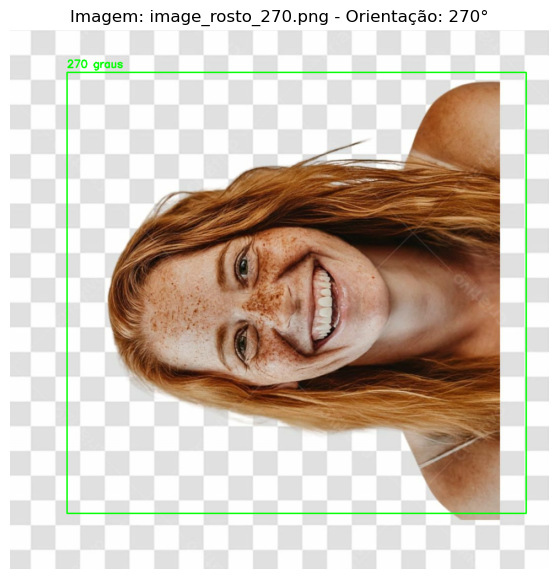

In [43]:
%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt
# Imagem de entrada
input_image = 'images_teste/image_rosto_270.png' 

templates = {                      #
    0:   'images_template/png-clipart-faces-faces_0.png', 
    90:  'images_template/png-clipart-faces-faces_90.png',
    180: 'images_template/png-clipart-faces-faces_180.png',
    270: 'images_template/png-clipart-faces-faces_270.png'
}

# Carrega a imagem de entrada
img_bgr = cv2.imread(input_image)

# Prossegue apenas se a imagem foi carregada 
if img_bgr is not None:
    # Converte a imagem para escala de cinza e obtém suas dimensões
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_h, img_w = img_gray.shape[:2]

    # Inicializa variáveis para guardar o melhor resultado encontrado
    best_orientation = None
    highest_score = -1.0  # Score inicial inválido (TM_CCOEFF_NORMED vai de -1 a 1)
    best_location = None
    best_template_dims = None

    # Itera sobre cada template definido
    for orientation, template_path in templates.items():
        # Carrega a imagem do template
        template_bgr = cv2.imread(template_path)

        # Pula este template se não puder ser carregado
        if template_bgr is None:
            continue

        # Obtém dimensões do template
        template_h, template_w = template_bgr.shape[:2]

        # Pula este template se for maior que a imagem de entrada (regra do matchTemplate)
        if template_h > img_h or template_w > img_w:
            continue

        # Converte o template para escala de cinza
        template_gray = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)

        # Realiza a comparação (Template Matching)
        result = cv2.matchTemplate(img_gray, template_gray, cv2.TM_CCOEFF_NORMED)

        # Encontra o ponto de maior similaridade (score e localização)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

        # Se o score deste template for o maior encontrado até agora, guarda seus dados
        if max_val > highest_score:
            highest_score = max_val
            best_orientation = orientation
            best_location = max_loc
            best_template_dims = (template_w, template_h)

    # Após testar todos os templates, verifica se um resultado foi encontrado
    if best_orientation is not None:
        print(f"Orientação encontrada: {best_orientation}° (Score: {highest_score:.4f}) na posição {best_location}")

        # Desenha um retângulo e o texto da orientação na imagem original
        top_left = best_location
        bottom_right = (top_left[0] + best_template_dims[0], top_left[1] + best_template_dims[1])
        cv2.rectangle(img_bgr, top_left, bottom_right, (0, 255, 0), 2) # Retângulo verde
        cv2.putText(img_bgr, f"{best_orientation} graus", (top_left[0], top_left[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2) # Texto verde

        # Converte a imagem de BGR (OpenCV) para RGB (Matplotlib) e a exibe
        plt.figure(figsize=(7, 7)) 
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f"Imagem: {input_image} - Orientação: {best_orientation}°") # Adiciona título
        plt.axis('off') 
        plt.show()

    else:
        print("Nenhuma orientação pôde ser determinada.")

else:
    print(f"Erro: Imagem de entrada '{input_image}' não encontrada ou inválida.")